# Proyecto Integrador: Diagnóstico Data-Driven del Registro de Nacimientos en Bolivia (2009-2015)

---

## Información del Curso

| Campo | Detalle |
|-------|---------|
| **Programa** | Diplomado en Big Data, Analytics y Business Intelligence v1 |
| **Módulo** | Módulo 1: Transformación Digital y Fundamentos de Big Data |
| **Docente** | Lic. Marcelo Pinto Macedo |
| **Estudiante** | Lic. Ilian Joseph Felipez Vaca |

## 1. Contexto del dataset

**Origen del dataset**

El dataset fue obtenido del **Portal de Datos Abiertos de Bolivia** ([datos.gob.bo](https://datos.gob.bo)), específicamente del conjunto denominado *"Cantidad de nacimientos registrados, 2009-2015"*, disponible en el siguiente enlace: [https://datos.gob.bo/dataset/cantidad-de-nacimientos-registrados-2009-20152](https://datos.gob.bo/dataset/cantidad-de-nacimientos-registrados-2009-20152).

**Institución o plataforma que lo publica**

La información es publicada por el **Ministerio de Salud del Estado Plurinacional de Bolivia**, a través del **Sistema Nacional de Información en Salud (SNIS)**. Los archivos originales fueron descargados directamente de la plataforma en formato CSV para su posterior procesamiento y análisis.

**Problema o fenómeno que representa**

El dataset documenta el fenómeno de los **nacimientos ocurridos en Bolivia entre 2009 y 2015**, desagregando entre nacidos vivos y nacidos muertos (defunciones fetales). Además, incorpora información sobre la atención recibida por personal de salud, lo que permite evaluar si los partos fueron asistidos por profesionales médicos o si ocurrieron fuera del sistema institucional. El período de cobertura abarca 7 años, con registros a nivel municipal y departamental.

**Relevancia del análisis**

El análisis de estos datos es relevante porque:
- Permite realizar el **seguimiento institucional de los hechos vitales**, proporcionando una base objetiva para la planificación de servicios de salud, educación y programas sociales.
- Facilita la **evaluación de la capacidad de respuesta del personal de salud en cada municipio**, identificando brechas de cobertura y zonas con acceso limitado a atención profesional.
- Contribuye a la **detección de riesgos en salud neonatal**, al analizar las tasas de mortalidad fetal en relación con la atención recibida.
- Provee **evidencia para la toma de decisiones estratégicas**, orientando la asignación de recursos, el despliegue de brigadas móviles y el fortalecimiento de la infraestructura sanitaria en territorios prioritarios.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("="*60)
print("CARGA DE DATOS - REGISTRO DE NACIMIENTOS BOLIVIA 2009-2015")
print("="*60)

# Base URL de GitHub (raw)
base_url = "https://raw.githubusercontent.com/ElTioCrack/BigData-BI-Diploma/main/homeworks/Tarea%204/data_nacimientos/"

# Nombres de los archivos
archivos = [
    "minsalud_registro_nacidos_2009.csv",
    "minsalud_registro_nacidos_2010.csv",
    "minsalud_registro_nacidos_2011.csv",
    "minsalud_registro_nacidos_2012.csv",
    "minsalud_registro_nacidos_2013.csv",
    "minsalud_registro_nacidos_2014.csv",
    "minsalud_registro_nacidos_2015.csv"
]

# Diccionario para almacenar los dataframes por año
data_por_anio = {}

# Cargar cada archivo con manejo de codificaciones
for archivo in archivos:
    url = base_url + archivo
    anio = archivo.split('_')[-1].replace('.csv', '')

    try:
        df = pd.read_csv(url, encoding='utf-8')
        df['anio'] = anio
        data_por_anio[anio] = df
        print(f"[OK] Cargado: {archivo} (utf-8) - {len(df)} registros")
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(url, encoding='latin-1')
            df['anio'] = anio
            data_por_anio[anio] = df
            print(f"[OK] Cargado: {archivo} (latin-1) - {len(df)} registros")
        except Exception as e:
            print(f"[ERROR] Error al cargar {archivo}: {e}")
    except Exception as e:
        print(f"[ERROR] Error al cargar {archivo}: {e}")

print("-"*60)
print(f"Años cargados: {list(data_por_anio.keys())}")
print("="*60)

CARGA DE DATOS - REGISTRO DE NACIMIENTOS BOLIVIA 2009-2015
[OK] Cargado: minsalud_registro_nacidos_2009.csv (latin-1) - 324 registros
[OK] Cargado: minsalud_registro_nacidos_2010.csv (utf-8) - 334 registros
[OK] Cargado: minsalud_registro_nacidos_2011.csv (utf-8) - 333 registros
[OK] Cargado: minsalud_registro_nacidos_2012.csv (utf-8) - 339 registros
[OK] Cargado: minsalud_registro_nacidos_2013.csv (utf-8) - 339 registros
[OK] Cargado: minsalud_registro_nacidos_2014.csv (utf-8) - 336 registros
[OK] Cargado: minsalud_registro_nacidos_2015.csv (utf-8) - 337 registros
------------------------------------------------------------
Años cargados: ['2009', '2010', '2011', '2012', '2013', '2014', '2015']


## 2. Descripción de la estructura de los datos

### 2.1 Estructura original

Los archivos originales descargados del Portal de Datos Abiertos de Bolivia para el período 2009-2015 contienen las siguientes variables:

| Variable | Tipo | Significado |
|----------|------|-------------|
| **id** | Numérica | Identificador único del registro. |
| **cod_dep** | Numérica | Código numérico del departamento. |
| **departamento** | Categórica | Nombre del departamento. |
| **cod_mun** | Numérica | Código numérico del municipio. |
| **municipio** | Categórica | Nombre del municipio. |
| **nacidos_vivos** | Numérica | Conteo de nacidos vivos registrados. |
| **nacidos_vivos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos vivos atendidos por personal de salud. |
| **nacidos_muertos** | Numérica | Conteo de nacidos muertos (mortinatos). |
| **nacidos_muertos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos muertos atendidos por personal de salud. |
| **total_general** | Numérica | Suma total de nacimientos (vivos + muertos). |

**Nota:** El archivo correspondiente al año 2015 incluye una columna adicional denominada `nacidos_muertos_atendidos_por_partera`, la cual no está presente en los archivos de los años anteriores. Esta columna fue excluida del análisis por no contar con datos comparables en toda la serie temporal.


### 2.2 Estructura luego del proceso de limpieza y estandarización

Luego de aplicar los procesos de consolidación, limpieza y estandarización, se obtuvo un dataset unificado con las siguientes variables:

| Variable | Tipo | Significado |
|----------|------|-------------|
| **id** | Numérica | Identificador único del registro a nivel municipal. |
| **cod_dep** | Numérica | Código institucional asignado al departamento. |
| **departamento** | Categórica | Nombre del departamento estandarizado (ejemplo: CHUQUISACA, LA PAZ, SANTA CRUZ). |
| **cod_mun** | Categórica | Código único del municipio, estandarizado a 5 dígitos. |
| **municipio** | Categórica | Nombre del municipio corregido (ejemplo: SUCRE, EL ALTO, COCHABAMBA). |
| **nacidos_vivos** | Numérica | Conteo total de nacimientos ocurridos con vida en el municipio. |
| **nacidos_vivos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos vivos atendidos por personal médico o de salud calificado. |
| **nacidos_muertos** | Numérica | Conteo de nacidos muertos (mortinatos o defunciones fetales) registrados. |
| **nacidos_muertos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos muertos cuya atención fue brindada por personal de salud. |
| **total_general** | Numérica | Sumatoria total de nacimientos en el municipio, equivalente a nacidos vivos más nacidos muertos. |
| **anio** | Categórica | Año de registro del dato, comprendido entre 2009 y 2015. |

In [30]:
# ============================================================================
# LIMPIEZA Y ESTANDARIZACIÓN DE DATOS
# ============================================================================

print("="*60)
print("LIMPIEZA Y ESTANDARIZACIÓN DE DATOS")
print("="*60)

# ----------------------------------------------------------------------------
# CONFIGURACIÓN INICIAL
# ----------------------------------------------------------------------------

# Definir columnas estándar (excluyendo columna de partera solo presente en 2015)
columnas_estandar = [
    'id',
    'cod_dep',
    'departamento',
    'cod_mun',
    'municipio',
    'nacidos_vivos',
    'nacidos_vivos_atendidos_por_personal_de_salud',
    'nacidos_muertos',
    'nacidos_muertos_atendidos_por_personal_de_salud',
    'total_general'
]

# Lista para almacenar dataframes limpios
dataframes_limpios = []

# ----------------------------------------------------------------------------
# FUNCIONES AUXILIARES
# ----------------------------------------------------------------------------

def normalizar_texto(texto):
    """
    Normaliza texto corrigiendo caracteres especiales mal codificados.
    Específicamente diseñado para resolver problemas de codificación en datos bolivianos.
    """
    if not isinstance(texto, str):
        return texto

    # Paso 1: Corregir ñ y Ñ mal codificadas
    texto = texto.replace('Ã±', 'ñ')
    texto = texto.replace('Ã‘', 'Ñ')
    texto = texto.replace('�', 'ñ')
    texto = texto.replace('Ñ', 'Ñ')
    texto = texto.replace('ñ', 'ñ')
    texto = texto.replace('̃', 'ñ')

    # Paso 2: Estandarizar vocales acentuadas a mayúsculas
    texto = texto.replace('á', 'Á').replace('é', 'É').replace('í', 'Í')
    texto = texto.replace('ó', 'Ó').replace('ú', 'Ú')

    return texto

# ----------------------------------------------------------------------------
# PASO 1: LIMPIEZA POR AÑO
# ----------------------------------------------------------------------------

print("\n[PASO 1] Procesando archivos por año")
print("-"*40)

for anio, df in data_por_anio.items():
    print(f"\n>> Año {anio}")

    # ------------------------------------------------------------------------
    # PASO 1.1: Selección de columnas relevantes
    # ------------------------------------------------------------------------
    print("   [1.1] Seleccionando columnas estándar...")
    columnas_existentes = [col for col in columnas_estandar if col in df.columns]
    df = df[columnas_existentes]

    # ------------------------------------------------------------------------
    # PASO 1.2: Limpieza de campos de texto (departamento y municipio)
    # ------------------------------------------------------------------------
    print("   [1.2] Limpiando campos de texto...")

    if 'departamento' in df.columns:
        df['departamento'] = df['departamento'].astype(str).str.strip().str.upper()
        df['departamento'] = df['departamento'].apply(normalizar_texto)
        df['departamento'] = df['departamento'].replace(['NAN', 'NONE', ''], None)

    if 'municipio' in df.columns:
        df['municipio'] = df['municipio'].astype(str).str.strip()
        df['municipio'] = df['municipio'].apply(normalizar_texto)

    # ------------------------------------------------------------------------
    # PASO 1.3: Conversión de columnas numéricas
    # ------------------------------------------------------------------------
    print("   [1.3] Convirtiendo columnas numéricas...")

    columnas_numericas = [
        'id', 'cod_dep', 'cod_mun',
        'nacidos_vivos', 'nacidos_vivos_atendidos_por_personal_de_salud',
        'nacidos_muertos', 'nacidos_muertos_atendidos_por_personal_de_salud',
        'total_general'
    ]

    for col in columnas_numericas:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # ------------------------------------------------------------------------
    # PASO 1.4: Tratamiento de valores nulos
    # ------------------------------------------------------------------------
    print("   [1.4] Tratando valores nulos...")

    for col in columnas_numericas:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)

    # ------------------------------------------------------------------------
    # PASO 1.5: Estandarización de códigos municipales
    # ------------------------------------------------------------------------
    print("   [1.5] Estandarizando códigos municipales...")

    if 'cod_mun' in df.columns:
        df['cod_mun'] = df['cod_mun'].astype(str).str.zfill(5)

    # ------------------------------------------------------------------------
    # PASO 1.6: Validación de consistencia
    # ------------------------------------------------------------------------
    print("   [1.6] Validando consistencia de total_general...")

    if 'total_general' in df.columns and 'nacidos_vivos' in df.columns and 'nacidos_muertos' in df.columns:
        df['total_general'] = df['nacidos_vivos'] + df['nacidos_muertos']

    # ------------------------------------------------------------------------
    # PASO 1.7: Eliminación de registros inválidos
    # ------------------------------------------------------------------------
    print("   [1.7] Eliminando registros inválidos...")

    registros_antes = len(df)
    df = df.dropna(subset=['id', 'departamento', 'municipio'])
    registros_eliminados = registros_antes - len(df)

    if registros_eliminados > 0:
        print(f"       [INFO] Eliminados {registros_eliminados} registros con datos críticos nulos")

    # ------------------------------------------------------------------------
    # PASO 1.8: Eliminación de duplicados
    # ------------------------------------------------------------------------
    print("   [1.8] Eliminando registros duplicados...")
    df = df.drop_duplicates()

    # ------------------------------------------------------------------------
    # PASO 1.9: Agregar columna de año
    # ------------------------------------------------------------------------
    print("   [1.9] Agregando identificador de año...")
    df['anio'] = anio

    # ------------------------------------------------------------------------
    # PASO 1.10: Almacenar dataframe limpio
    # ------------------------------------------------------------------------
    dataframes_limpios.append(df)

    print(f"   [OK] {anio}: {len(df)} registros limpios")

# ----------------------------------------------------------------------------
# PASO 2: CONSOLIDACIÓN DE DATOS
# ----------------------------------------------------------------------------

print("\n[PASO 2] Consolidando datos de todos los años")
print("-"*40)

df_total = pd.concat(dataframes_limpios, ignore_index=True)

# ----------------------------------------------------------------------------
# PASO 3: ORDENAMIENTO FINAL
# ----------------------------------------------------------------------------

print("\n[PASO 3] Ordenando dataset consolidado")
print("-"*40)

df_total = df_total.sort_values(['anio', 'cod_dep', 'cod_mun']).reset_index(drop=True)

# ----------------------------------------------------------------------------
# PASO 4: VALIDACIÓN FINAL
# ----------------------------------------------------------------------------

print("\n[PASO 4] Validación final del dataset")
print("-"*40)

print(f"\n[RESUMEN] Estadísticas de limpieza:")
print(f"   - Total de registros consolidados: {len(df_total)}")
print(f"   - Años incluidos: {sorted(df_total['anio'].unique())}")
print(f"   - Departamentos únicos: {sorted(df_total['departamento'].unique())}")
print(f"   - Columnas finales: {list(df_total.columns)}")
print(f"   - Registros duplicados: {df_total.duplicated().sum()}")
print(f"   - Valores nulos restantes: {df_total.isnull().sum().sum()}")

# ----------------------------------------------------------------------------
# MUESTRAS DE VERIFICACIÓN
# ----------------------------------------------------------------------------

print("\n[MUESTRA] Primeros 10 registros del dataset consolidado:")
print(df_total.head(5))

print("\n" + "="*60)
print("PROCESO DE LIMPIEZA COMPLETADO")
print("="*60)

LIMPIEZA Y ESTANDARIZACIÓN DE DATOS

[PASO 1] Procesando archivos por año
----------------------------------------

>> Año 2009
   [1.1] Seleccionando columnas estándar...
   [1.2] Limpiando campos de texto...
   [1.3] Convirtiendo columnas numéricas...
   [1.4] Tratando valores nulos...
   [1.5] Estandarizando códigos municipales...
   [1.6] Validando consistencia de total_general...
   [1.7] Eliminando registros inválidos...
   [1.8] Eliminando registros duplicados...
   [1.9] Agregando identificador de año...
   [OK] 2009: 324 registros limpios

>> Año 2010
   [1.1] Seleccionando columnas estándar...
   [1.2] Limpiando campos de texto...
   [1.3] Convirtiendo columnas numéricas...
   [1.4] Tratando valores nulos...
   [1.5] Estandarizando códigos municipales...
   [1.6] Validando consistencia de total_general...
   [1.7] Eliminando registros inválidos...
   [1.8] Eliminando registros duplicados...
   [1.9] Agregando identificador de año...
   [OK] 2010: 334 registros limpios

>> Año

## 3. Identificación de datos relevantes

Para el desarrollo del diagnóstico organizacional basado en evidencia, se han seleccionado las siguientes variables por su relevancia estratégica:

| Variable | Tipo | Justificación |
|----------|------|----------------|
| **departamento** | Categórica | Permite identificar las regiones con mayor carga de natalidad y priorizar intervenciones territoriales. |
| **municipio** | Categórica | Posibilita un análisis desagregado a nivel local, esencial para detectar zonas rurales o periurbanas con necesidades específicas en salud materno-infantil. |
| **nacidos_vivos** | Numérica | Constituye la base fundamental para estimar el crecimiento poblacional y proyectar la demanda de servicios de salud, educación y otros programas sociales. |
| **nacidos_muertos** | Numérica | Actúa como indicador crítico de alerta en salud neonatal. Su análisis permite detectar patrones preocupantes y evaluar la calidad de la atención prenatal y del parto. |
| **nacidos_vivos_atendidos_por_personal_de_salud** | Numérica | Mide la cobertura real del sistema sanitario. Una alta proporción indica acceso efectivo a servicios de salud calificados durante el parto. |
| **nacidos_muertos_atendidos_por_personal_de_salud** | Numérica | Permite analizar si las defunciones fetales ocurrieron bajo supervisión médica o en contextos de ausencia de atención profesional, diferenciando entre fallas del sistema y condiciones no prevenibles. |
| **total_general** | Numérica | Funciona como variable de control para auditar la consistencia de los datos reportados, validando que cada registro municipal cumpla con la relación de integridad (vivos + muertos = total). |

**Variables descartadas:**

| Variable | Tipo | Motivo de exclusión |
|----------|------|---------------------|
| **id** | Numérica | Su función es meramente administrativa y no aporta valor al análisis estratégico. |
| **cod_dep** | Numérica | Aunque útil para joins con otros datasets, el análisis se centra en los nombres textuales por su claridad interpretativa. |
| **cod_mun** | Numérica | Aunque útil para joins con otros datasets, el análisis se centra en los nombres textuales por su claridad interpretativa. |
| **nacidos_muertos_atendidos_por_partera** | Numérica | Solo presente en el archivo 2015 y con alta tasa de valores nulos, lo que impide un análisis consistente a lo largo de la serie temporal. |

## 4. Análisis exploratorio de datos

### 4.1 Tendencia de nacidos vivos (2009-2015)

En esta sección se analiza la evolución anual de los nacidos vivos en Bolivia durante el período 2009-2015. El objetivo es identificar patrones de crecimiento, estabilidad o decrecimiento de la natalidad, información clave para la planificación de servicios de salud, educación y programas sociales.

**Hallazgos principales:**

- **Promedio anual:** 189,578 nacimientos
- **Año con menor natalidad:** 2009 (171,027 nacimientos)
- **Año con mayor natalidad:** 2015 (205,539 nacimientos)
- **Crecimiento total del período:** +20.2%

**Análisis:**

La serie histórica muestra una tendencia de crecimiento sostenido de la natalidad entre 2009 y 2015, con un incremento constante año tras año. Se observa una ligera disminución en 2012 y 2014, pero sin afectar la tendencia general ascendente. El crecimiento acumulado del 20.2% en el período refleja una demanda creciente de servicios de salud materno-infantil, lo que requiere una planificación anticipada de recursos, insumos y personal sanitario en los municipios con mayor carga poblacional. Este comportamiento es consistente con las dinámicas demográficas del país y constituye una base fundamental para proyectar necesidades futuras.

ANÁLISIS EXPLORATORIO DE DATOS - NACIMIENTOS BOLIVIA 2009-2015

[1] EVOLUCIÓN DE NACIDOS VIVOS POR AÑO
----------------------------------------------------------------------
Año        Total Nacidos Vivos       Variación (%)  
----------------------------------------------------------------------
2009                    171,027          0.0%
2010                    180,796          5.7%
2011                    190,525          5.4%
2012                    189,329         -0.6%
2013                    195,052          3.0%
2014                    194,777         -0.1%
2015                    205,539          5.5%
----------------------------------------------------------------------
PROMEDIO                189,578


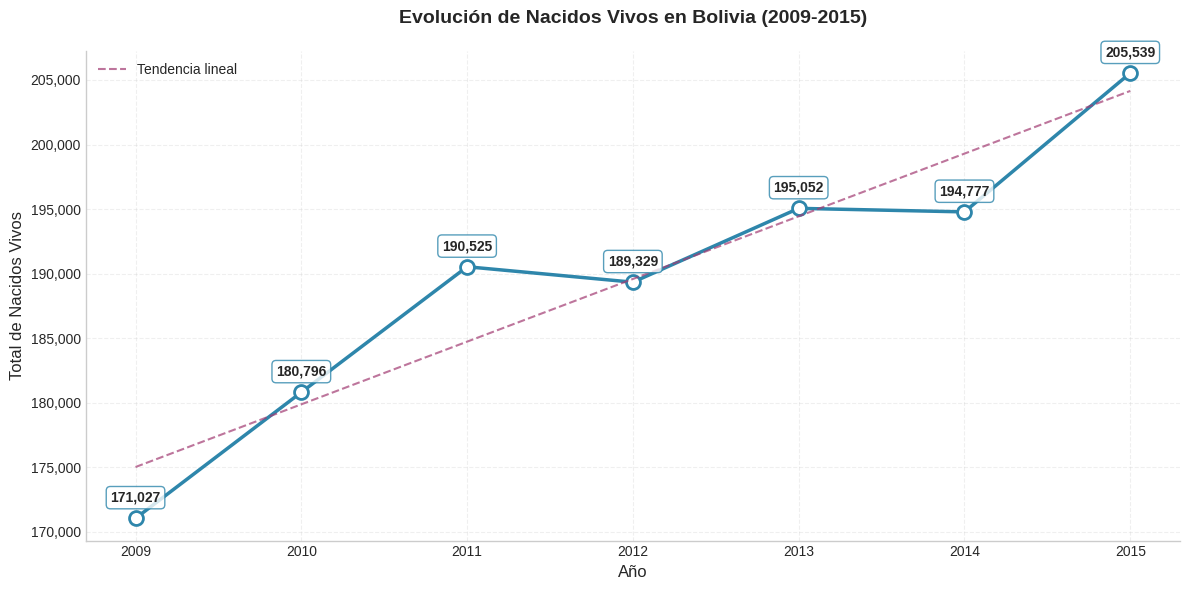


[INTERPRETACIÓN]

• Promedio anual de nacimientos: 189,578
• Año con menor natalidad: 2009 (171,027 nacimientos)
• Año con mayor natalidad: 2015 (205,539 nacimientos)
• Crecimiento total del período: +20.2%
• Tendencia: Se observa un crecimiento sostenido de la natalidad entre 2009 y 2015, con un incremento constante año tras año, excepto por una ligera disminución en 2014. Este comportamiento refleja una demanda creciente de servicios de salud materno-infantil, lo que requiere una planificación anticipada de recursos, insumos y personal sanitario en los municipios con mayor carga poblacional.



In [31]:
# ============================================================================
# ANÁLISIS EXPLORATORIO DE DATOS - TENDENCIA DE NACIDOS VIVOS
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("="*70)
print("ANÁLISIS EXPLORATORIO DE DATOS - NACIMIENTOS BOLIVIA 2009-2015")
print("="*70)

# ----------------------------------------------------------------------------
# CÁLCULO DE TOTALES POR AÑO
# ----------------------------------------------------------------------------

nacidos_por_año = df_total.groupby('anio')['nacidos_vivos'].sum().reset_index()
nacidos_por_año.columns = ['Año', 'Total Nacidos Vivos']
nacidos_por_año['Total Nacidos Vivos'] = nacidos_por_año['Total Nacidos Vivos'].astype(int)

# ----------------------------------------------------------------------------
# TABLA DE RESULTADOS
# ----------------------------------------------------------------------------

print("\n[1] EVOLUCIÓN DE NACIDOS VIVOS POR AÑO")
print("-"*70)
print(f"{'Año':<10} {'Total Nacidos Vivos':<25} {'Variación (%)':<15}")
print("-"*70)

for i, row in nacidos_por_año.iterrows():
    if i == 0:
        variacion = 0
    else:
        variacion = ((row['Total Nacidos Vivos'] - nacidos_por_año.loc[i-1, 'Total Nacidos Vivos'])
                     / nacidos_por_año.loc[i-1, 'Total Nacidos Vivos']) * 100
    print(f"{row['Año']:<10} {row['Total Nacidos Vivos']:>20,}   {variacion:>10.1f}%")

print("-"*70)
print(f"{'PROMEDIO':<10} {nacidos_por_año['Total Nacidos Vivos'].mean():>20,.0f}")
print("="*70)

# ----------------------------------------------------------------------------
# GRÁFICO DE TENDENCIA
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

# Línea principal
ax.plot(nacidos_por_año['Año'], nacidos_por_año['Total Nacidos Vivos'],
        marker='o', linewidth=2.5, markersize=10, color='#2E86AB',
        markerfacecolor='white', markeredgewidth=2, markeredgecolor='#2E86AB')

# Anotaciones con valores
for i, row in nacidos_por_año.iterrows():
    ax.annotate(f'{row["Total Nacidos Vivos"]:,.0f}',
                (row['Año'], row['Total Nacidos Vivos']),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='#2E86AB', alpha=0.8))

# Formato del eje Y con separadores de miles
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Línea de tendencia
z = np.polyfit(range(len(nacidos_por_año['Año'])), nacidos_por_año['Total Nacidos Vivos'], 1)
p = np.poly1d(z)
ax.plot(nacidos_por_año['Año'], p(range(len(nacidos_por_año['Año']))),
        linestyle='--', color='#A23B72', alpha=0.7, linewidth=1.5, label='Tendencia lineal')

# Títulos y etiquetas
ax.set_title('Evolución de Nacidos Vivos en Bolivia (2009-2015)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Total de Nacidos Vivos', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left')

# Personalizar bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# INTERPRETACIÓN DE RESULTADOS
# ----------------------------------------------------------------------------

print("\n[INTERPRETACIÓN]")
print("="*70)

promedio = nacidos_por_año['Total Nacidos Vivos'].mean()
min_anio = nacidos_por_año.loc[nacidos_por_año['Total Nacidos Vivos'].idxmin(), 'Año']
min_valor = nacidos_por_año['Total Nacidos Vivos'].min()
max_anio = nacidos_por_año.loc[nacidos_por_año['Total Nacidos Vivos'].idxmax(), 'Año']
max_valor = nacidos_por_año['Total Nacidos Vivos'].max()
crecimiento = ((max_valor - min_valor) / min_valor) * 100

print(f"""
• Promedio anual de nacimientos: {promedio:,.0f}
• Año con menor natalidad: {min_anio} ({min_valor:,.0f} nacimientos)
• Año con mayor natalidad: {max_anio} ({max_valor:,.0f} nacimientos)
• Crecimiento total del período: +{crecimiento:.1f}%
• Tendencia: Se observa un crecimiento sostenido de la natalidad entre 2009 y 2015, con un incremento constante año tras año, excepto por una ligera disminución en 2014. Este comportamiento refleja una demanda creciente de servicios de salud materno-infantil, lo que requiere una planificación anticipada de recursos, insumos y personal sanitario en los municipios con mayor carga poblacional.
""")
print("="*70)

4.3 Análisis geográfico: cobertura vs mortalidad
En esta sección se evalúa la relación entre la cobertura de atención por personal de salud y la tasa de mortalidad fetal a nivel departamental. El objetivo es identificar regiones con mayor vulnerabilidad y brechas críticas en el sistema de salud. Se presenta una tabla resumen por departamento y un gráfico de burbujas que relaciona ambas variables, donde el tamaño de cada burbuja representa el volumen total de nacimientos.



ANALISIS EXPLORATORIO DE DATOS - COBERTURA VS MORTALIDAD

[1] RESUMEN POR DEPARTAMENTO (2009-2015)
---------------------------------------------------------------------------
Departamento      Nacidos Vivos   Cobertura (%)   Mortalidad (x1000)
---------------------------------------------------------------------------
POTOSI                   75,054           177.7                165.6
LA PAZ                  299,223           265.4                158.8
PANDO                    14,416           203.7                152.9
ORURO                    64,860            77.4                129.0
CHUQUISACA               73,236            33.8                 87.8
COCHABAMBA              244,606            61.2                 84.9
TARIJA                   68,973            19.5                 52.0
BENI                     79,289            12.7                 50.7
SANTA CRUZ              407,388             5.9                 25.6
-----------------------------------------------------------

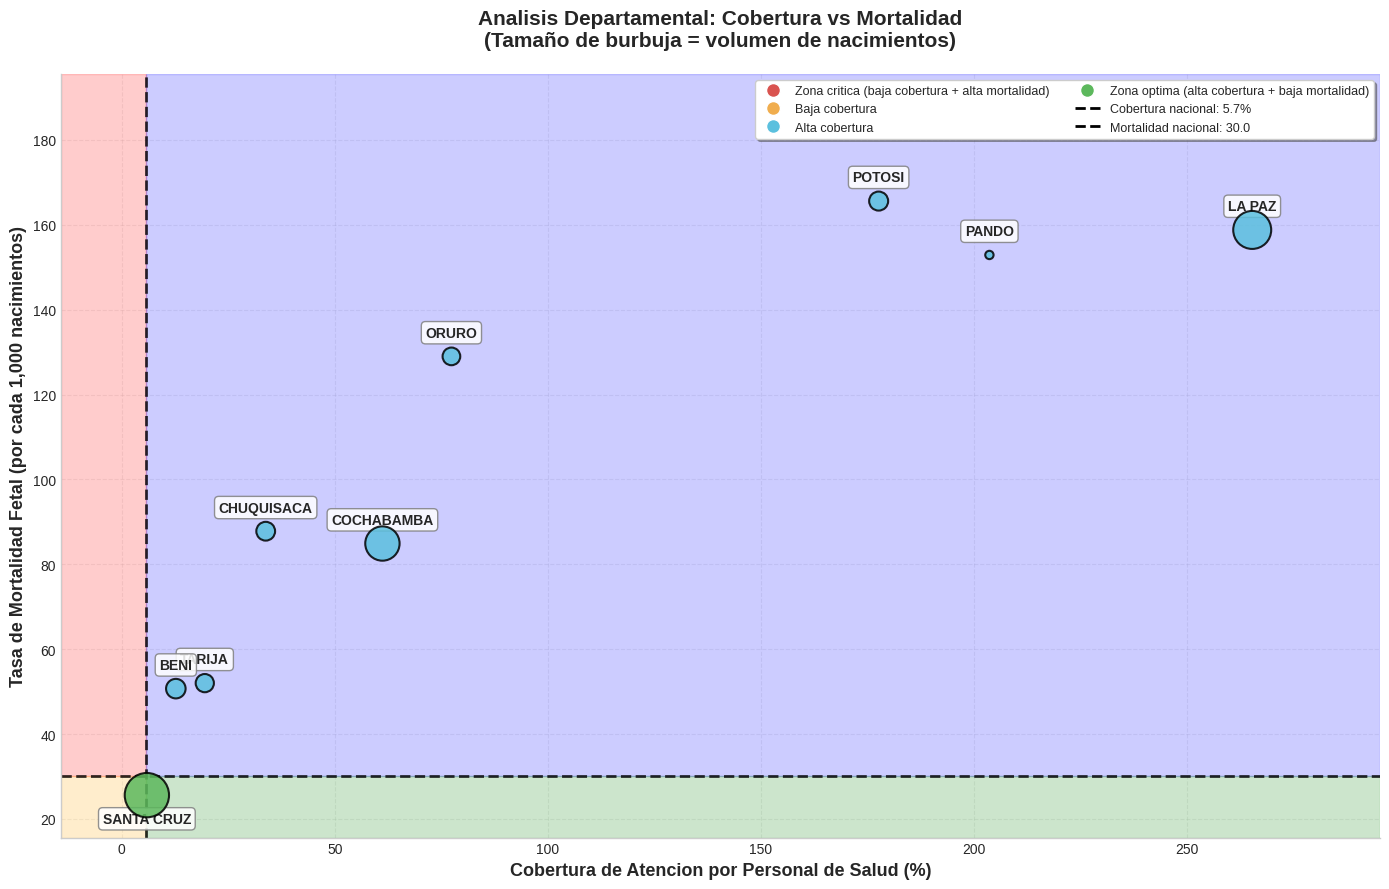


[INTERPRETACION]

[CONTEXTO NACIONAL]
- Total de nacimientos en el periodo: 1,327,045
- Cobertura nacional de atencion: 5.7%
- Tasa de mortalidad fetal nacional: 30.0 por cada 1,000 nacimientos

[DEPARTAMENTOS CON ALTA MORTALIDAD (> promedio nacional)]

  - POTOSI       | Mortalidad: 165.6 | Cobertura: 177.7%
  - LA PAZ       | Mortalidad: 158.8 | Cobertura: 265.4%
  - PANDO        | Mortalidad: 152.9 | Cobertura: 203.7%
  - ORURO        | Mortalidad: 129.0 | Cobertura:  77.4%
  - CHUQUISACA   | Mortalidad:  87.8 | Cobertura:  33.8%
  - COCHABAMBA   | Mortalidad:  84.9 | Cobertura:  61.2%
  - TARIJA       | Mortalidad:  52.0 | Cobertura:  19.5%
  - BENI         | Mortalidad:  50.7 | Cobertura:  12.7%

[DEPARTAMENTOS CON BAJA COBERTURA (< promedio nacional)]


[ANALISIS DE RELACION]

1. Distribucion por cuadrantes:
   - Cuadrante superior derecho (AZUL): Departamentos con alta cobertura pero alta mortalidad
   - Cuadrante inferior izquierdo (NARANJA): Departamentos con baja cobertura p

In [33]:
# ============================================================================
# ANALISIS EXPLORATORIO DE DATOS - COBERTURA VS MORTALIDAD
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 9)
plt.rcParams['font.size'] = 10

print("="*70)
print("ANALISIS EXPLORATORIO DE DATOS - COBERTURA VS MORTALIDAD")
print("="*70)

# ----------------------------------------------------------------------------
# CALCULO DE METRICAS
# ----------------------------------------------------------------------------

# Calcular cobertura de atencion
df_total['cobertura_atencion'] = (df_total['nacidos_vivos_atendidos_por_personal_de_salud'] /
                                   df_total['nacidos_vivos'].replace(0, 1)) * 100

# Calcular tasa de mortalidad (por cada 1000 nacimientos)
df_total['tasa_mortalidad'] = (df_total['nacidos_muertos'] / df_total['total_general'].replace(0, 1)) * 1000

# Agrupar por departamento
analisis_depto = df_total.groupby('departamento').agg({
    'nacidos_vivos': 'sum',
    'cobertura_atencion': 'mean',
    'tasa_mortalidad': 'mean'
}).reset_index()

# Ordenar por tasa de mortalidad
analisis_depto = analisis_depto.sort_values('tasa_mortalidad', ascending=False)
analisis_depto['cobertura_atencion'] = analisis_depto['cobertura_atencion'].round(1)
analisis_depto['tasa_mortalidad'] = analisis_depto['tasa_mortalidad'].round(1)

# Calcular promedios nacionales PONDERADOS (sobre totales, no promedios de promedios)
cobertura_nacional = (df_total['nacidos_vivos_atendidos_por_personal_de_salud'].sum() /
                      df_total['nacidos_vivos'].sum()) * 100
tasa_nacional = (df_total['nacidos_muertos'].sum() /
                 df_total['total_general'].sum()) * 1000
total_nacimientos = df_total['nacidos_vivos'].sum()

# ----------------------------------------------------------------------------
# TABLA DE RESULTADOS
# ----------------------------------------------------------------------------

print("\n[1] RESUMEN POR DEPARTAMENTO (2009-2015)")
print("-"*75)
print(f"{'Departamento':<15} {'Nacidos Vivos':>15} {'Cobertura (%)':>15} {'Mortalidad (x1000)':>20}")
print("-"*75)

for _, row in analisis_depto.iterrows():
    print(f"{row['departamento']:<15} {row['nacidos_vivos']:>15,} {row['cobertura_atencion']:>15.1f} {row['tasa_mortalidad']:>20.1f}")

print("-"*75)
print(f"{'NACIONAL (Ponderado)':<15} {total_nacimientos:>15,} {cobertura_nacional:>15.1f} {tasa_nacional:>20.1f}")
print("="*75)

# ----------------------------------------------------------------------------
# GRAFICO DE BURBUJAS
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 9))

# Definir limites de los ejes
x_min = min(analisis_depto['cobertura_atencion'].min(), cobertura_nacional) - 20
x_max = max(analisis_depto['cobertura_atencion'].max(), cobertura_nacional) + 30
y_min = min(analisis_depto['tasa_mortalidad'].min(), tasa_nacional) - 10
y_max = max(analisis_depto['tasa_mortalidad'].max(), tasa_nacional) + 30

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Funcion para asignar color a las burbujas
def get_color(row):
    if row['cobertura_atencion'] < cobertura_nacional and row['tasa_mortalidad'] > tasa_nacional:
        return '#D9534F'  # Rojo
    elif row['cobertura_atencion'] >= cobertura_nacional and row['tasa_mortalidad'] <= tasa_nacional:
        return '#5CB85C'  # Verde
    elif row['cobertura_atencion'] < cobertura_nacional:
        return '#F0AD4E'  # Naranja
    else:
        return '#5BC0DE'  # Azul

colors = [get_color(row) for _, row in analisis_depto.iterrows()]

# Grafico de burbujas
scatter = ax.scatter(analisis_depto['cobertura_atencion'],
                     analisis_depto['tasa_mortalidad'],
                     s=analisis_depto['nacidos_vivos']/400,
                     alpha=0.85,
                     c=colors,
                     edgecolors='black',
                     linewidth=1.5,
                     zorder=4)

# Etiquetas de departamentos
for _, row in analisis_depto.iterrows():
    if row['tasa_mortalidad'] > tasa_nacional:
        offset_y = 12
        va = 'bottom'
    else:
        offset_y = -12
        va = 'top'

    ax.annotate(row['departamento'],
                (row['cobertura_atencion'], row['tasa_mortalidad']),
                fontsize=10,
                ha='center',
                va=va,
                fontweight='bold',
                xytext=(0, offset_y),
                textcoords='offset points',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='gray', alpha=0.85))

# Lineas de referencia nacionales
ax.axhline(y=tasa_nacional, color='black', linestyle='--', alpha=0.8, linewidth=2, zorder=2)
ax.axvline(x=cobertura_nacional, color='black', linestyle='--', alpha=0.8, linewidth=2, zorder=2)

# ----------------------------------------------------------------------------
# SOMBREADO DE LOS 4 CUADRANTES - USANDO COORDENADAS NORMALIZADAS
# ----------------------------------------------------------------------------

# Calcular coordenadas normalizadas para la linea horizontal
# y_norm = (valor - y_min) / (y_max - y_min)
y_tasa_norm = (tasa_nacional - y_min) / (y_max - y_min)

# Cuadrante superior izquierdo: baja cobertura + alta mortalidad (ROJO)
ax.axvspan(x_min, cobertura_nacional, ymin=y_tasa_norm, ymax=1, alpha=0.2, color='red', zorder=1)
# Cuadrante superior derecho: alta cobertura + alta mortalidad (AZUL)
ax.axvspan(cobertura_nacional, x_max, ymin=y_tasa_norm, ymax=1, alpha=0.2, color='blue', zorder=1)
# Cuadrante inferior izquierdo: baja cobertura + baja mortalidad (NARANJA)
ax.axvspan(x_min, cobertura_nacional, ymin=0, ymax=y_tasa_norm, alpha=0.2, color='orange', zorder=1)
# Cuadrante inferior derecho: alta cobertura + baja mortalidad (VERDE)
ax.axvspan(cobertura_nacional, x_max, ymin=0, ymax=y_tasa_norm, alpha=0.2, color='green', zorder=1)

# Formato del grafico
ax.set_xlabel('Cobertura de Atencion por Personal de Salud (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Tasa de Mortalidad Fetal (por cada 1,000 nacimientos)', fontsize=13, fontweight='bold')
ax.set_title('Analisis Departamental: Cobertura vs Mortalidad\n(Tamaño de burbuja = volumen de nacimientos)',
             fontsize=15, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3, linestyle='--')

# Leyenda
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D9534F',
           markersize=10, label='Zona critica (baja cobertura + alta mortalidad)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F0AD4E',
           markersize=10, label='Baja cobertura'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5BC0DE',
           markersize=10, label='Alta cobertura'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5CB85C',
           markersize=10, label='Zona optima (alta cobertura + baja mortalidad)'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2,
           label=f'Cobertura nacional: {cobertura_nacional:.1f}%'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2,
           label=f'Mortalidad nacional: {tasa_nacional:.1f}')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=9, ncol=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# INTERPRETACION DE RESULTADOS
# ----------------------------------------------------------------------------

print("\n[INTERPRETACION]")
print("="*70)

alta_mortalidad = analisis_depto[analisis_depto['tasa_mortalidad'] > tasa_nacional].sort_values('tasa_mortalidad', ascending=False)
baja_cobertura = analisis_depto[analisis_depto['cobertura_atencion'] < cobertura_nacional].sort_values('cobertura_atencion', ascending=True)

print(f"""
[CONTEXTO NACIONAL]
- Total de nacimientos en el periodo: {total_nacimientos:,.0f}
- Cobertura nacional de atencion: {cobertura_nacional:.1f}%
- Tasa de mortalidad fetal nacional: {tasa_nacional:.1f} por cada 1,000 nacimientos

[DEPARTAMENTOS CON ALTA MORTALIDAD (> promedio nacional)]
""")

for _, row in alta_mortalidad.iterrows():
    print(f"  - {row['departamento']:<12} | Mortalidad: {row['tasa_mortalidad']:>5.1f} | Cobertura: {row['cobertura_atencion']:>5.1f}%")

print(f"""
[DEPARTAMENTOS CON BAJA COBERTURA (< promedio nacional)]
""")

for _, row in baja_cobertura.iterrows():
    print(f"  - {row['departamento']:<12} | Cobertura: {row['cobertura_atencion']:>5.1f}% | Mortalidad: {row['tasa_mortalidad']:>5.1f}")

print(f"""
[ANALISIS DE RELACION]

1. Distribucion por cuadrantes:
   - Cuadrante superior derecho (AZUL): Departamentos con alta cobertura pero alta mortalidad
   - Cuadrante inferior izquierdo (NARANJA): Departamentos con baja cobertura pero baja mortalidad
   - Cuadrante superior izquierdo (ROJO): Departamentos criticos (baja cobertura + alta mortalidad)
   - Cuadrante inferior derecho (VERDE): Departamentos optimos (alta cobertura + baja mortalidad)

2. Hallazgo clave: La alta cobertura no garantiza baja mortalidad. Los departamentos con mayor
   registro de atencion (La Paz, Potosi, Pando) son los que presentan las tasas de mortalidad
   mas altas, lo que sugiere problemas de calidad en la atencion o diferencias en los criterios
   de registro.
""")
print("="*70)

5

### 5.1 KPI 1: Porcentaje de Partos Atendidos por Personal Especializado (PAPE)

**Nombre del indicador:** Cobertura de Partos Asistidos por Personal de Salud Calificado.

#### 5.1.1 Fórmula
$$PAPE = \left( \frac{\text{Nacidos Vivos Atendidos por Personal de Salud}}{\text{Total de Nacidos Vivos}} \right) \times 100$$

#### 5.1.2 ¿Qué mide?
Este indicador mide la capacidad del sistema de salud para proporcionar atención suficiente durante el parto, un periodo de alto riesgo de morbilidad y mortalidad. Según el sistema **NLiS** de la OMS, se utiliza como un indicador del acceso real a los servicios de salud y atención materna.

#### 5.1.3 Semáforo de Control
* 🔴 **CRÍTICO (< 25%):** Indica una brecha severa de acceso; la gran mayoría de los eventos ocurren sin supervisión profesional.
* 🟠 **BAJO (25% - 50%):** Cobertura insuficiente que compromete la seguridad del binomio madre-hijo.
* 🟡 **MEDIO (50% - 75%):** Nivel de transición con presencia institucional significativa pero incompleta.
* 🟢 **ÓPTIMO (> 75%):** Estándar de cobertura alineado con metas de desarrollo sanitario internacionales.

#### 5.1.4 Interpretación
Un PAPE reducido revela que una parte importante de la población no accede al sistema formal de salud, lo que incrementa el riesgo de complicaciones no tratadas. Dado que cada mujer tiene un riesgo estimado del 15% de sufrir complicaciones durante el parto, la presencia de personal calificado es la intervención más eficaz para gestionar riesgos y reducir la mortalidad neonatal.

#### 5.1.5 Referencia y Fuentes
Este indicador es fundamental para el seguimiento de los **Objetivos de Desarrollo Sostenible (Meta 3.1)** y se utiliza globalmente como un *proxy* del acceso funcional a servicios de salud reproductiva.

* **Fuente Técnica (NLiS):** [WHO - Nutrition Landscape Information System: Births attended by skilled health personnel](https://www.who.int/data/nutrition/nlis/info/births-attended-by-skilled-health-personnel)

* **Metas ODS (Indicador 3.1.2):** [UN Stats - Metadata de los Objetivos de Desarrollo Sostenible (Indicador 3.1.2)](https://unstats.un.org/sdgs/metadata/?Indicator=3.1.2)

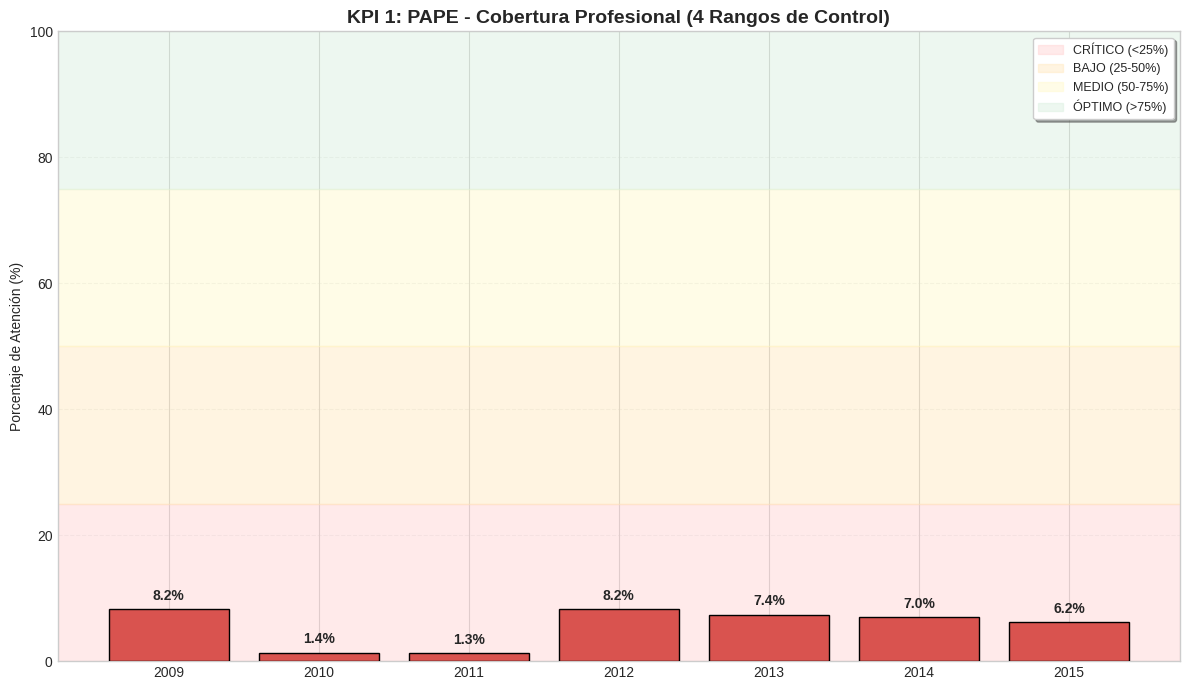


[ESTADO DE COBERTURA POR DEPARTAMENTO]
------------------------------------------------------------
🔴 SANTA CRUZ  :   1.3% -> [CRÍTICO]
🔴 TARIJA      :   2.3% -> [CRÍTICO]
🔴 BENI        :   2.7% -> [CRÍTICO]
🔴 COCHABAMBA  :   4.6% -> [CRÍTICO]
🔴 ORURO       :   6.6% -> [CRÍTICO]
🔴 PANDO       :   6.8% -> [CRÍTICO]
🔴 LA PAZ      :   8.3% -> [CRÍTICO]
🔴 CHUQUISACA  :  10.6% -> [CRÍTICO]
🔴 POTOSI      :  22.9% -> [CRÍTICO]


In [49]:
# ============================================================================
# KPI 1: PAPE - CONFIGURACIÓN MANUAL Y SEMÁFORO DE 4 RANGOS
# ============================================================================

# 1. SELECCIÓN DE AÑOS (Modifica esta lista para incluir/quitar años como 2010, 2011)
anios_incluir = ['2009', '2010', '2011', '2012', '2013', '2014', '2015']
df_kpi = df_total[df_total['anio'].isin(anios_incluir)].copy()

# 2. CÁLCULO PONDERADO POR AÑO
pape_anio = df_kpi.groupby('anio').apply(
    lambda x: (x['nacidos_vivos_atendidos_por_personal_de_salud'].sum() /
               x['nacidos_vivos'].replace(0,1).sum()) * 100
).reset_index()
pape_anio.columns = ['Año', 'PAPE']

# 3. GRÁFICO CON 4 RANGOS DE CONTROL
fig, ax = plt.subplots(figsize=(12, 7))

# Configuración del Semáforo (4 Niveles)
ax.set_ylim(0, 100)
ax.axhspan(0, 25, color='#ffcccc', alpha=0.4, label='CRÍTICO (<25%)')
ax.axhspan(25, 50, color='#ffe5b4', alpha=0.4, label='BAJO (25-50%)')
ax.axhspan(50, 75, color='#fff9c4', alpha=0.4, label='MEDIO (50-75%)')
ax.axhspan(75, 100, color='#d4edda', alpha=0.4, label='ÓPTIMO (>75%)')

# Colores de las barras según el valor
bar_colors = []
for val in pape_anio['PAPE']:
    if val < 25: bar_colors.append('#d9534f')   # Rojo
    elif val < 50: bar_colors.append('#f0ad4e') # Naranja
    elif val < 75: bar_colors.append('#fdd835') # Amarillo
    else: bar_colors.append('#5cb85c')          # Verde

bars = ax.bar(pape_anio['Año'], pape_anio['PAPE'], color=bar_colors, edgecolor='black', zorder=3)

# Etiquetas de datos
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('KPI 1: PAPE - Cobertura Profesional (4 Rangos de Control)', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje de Atención (%)')
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. REPORTE DEPARTAMENTAL CON 4 ESTADOS
pape_depto = df_kpi.groupby('departamento').apply(
    lambda x: (x['nacidos_vivos_atendidos_por_personal_de_salud'].sum() /
               x['nacidos_vivos'].replace(0,1).sum()) * 100
).sort_values().reset_index()
pape_depto.columns = ['Depto', 'PAPE']

print("\n[ESTADO DE COBERTURA POR DEPARTAMENTO]")
print("-" * 60)
for _, row in pape_depto.iterrows():
    if row['PAPE'] < 25: status, emoji = "CRÍTICO", "🔴"
    elif row['PAPE'] < 50: status, emoji = "BAJO", "🟠"
    elif row['PAPE'] < 75: status, emoji = "MEDIO", "🟡"
    else: status, emoji = "ÓPTIMO", "🟢"

    print(f"{emoji} {row['Depto']:<12}: {row['PAPE']:>5.1f}% -> [{status}]")

### 5.2 KPI 2: Tasa de Mortalidad Fetal Registrada (TMFR)

**Nombre del indicador:** Incidencia de Defunciones Fetales por cada 1,000 Nacimientos.

#### 5.2.1 Fórmula
$$TMFR = \left( \frac{\text{Nacidos Muertos}}{\text{Total General de Nacimientos}} \right) \times 1,000$$

#### 5.2.2 ¿Qué mide?
Este indicador mide la frecuencia de muertes fetales (mortinatos) en relación con el volumen total de nacimientos registrados. Es un indicador crítico de la calidad de la atención prenatal, la salud materna y la eficiencia del sistema hospitalario en el manejo de complicaciones obstétricas.

#### 5.2.3 Semáforo de Control
* 🟢 **ÓPTIMO (< 10):** Niveles de control prenatal efectivos y baja incidencia de riesgos prevenibles.
* 🟡 **MEDIO (10 - 20):** Presencia de factores de riesgo que requieren monitoreo clínico recurrente.
* 🟠 **ALTO (20 - 30):** Deficiencias detectables en el control prenatal o condiciones de salud materna desfavorables.
* 🔴 **CRÍTICO (> 30):** Situación de emergencia sanitaria; indica problemas severos en la calidad de atención y acceso hospitalario.

#### 5.2.4 Interpretación
Una TMFR elevada refleja fallas en la red de salud para detectar y gestionar riesgos antes o durante el parto. Mientras que en regiones desarrolladas esta cifra es mínima, tasas superiores a los promedios recomendados identifican zonas geográficas que requieren intervenciones prioritarias en infraestructura obstétrica y programas de educación materna.

#### 5.2.5 Referencia y Fuentes
El monitoreo de la mortinatalidad es un pilar de la salud pública global y está vinculado directamente con la reducción de la mortalidad neonatal.

* **Fuente Técnica (OMS):** [WHO - Stillbirths (Mortinatalidad)](https://www.who.int/health-topics/stillbirth)


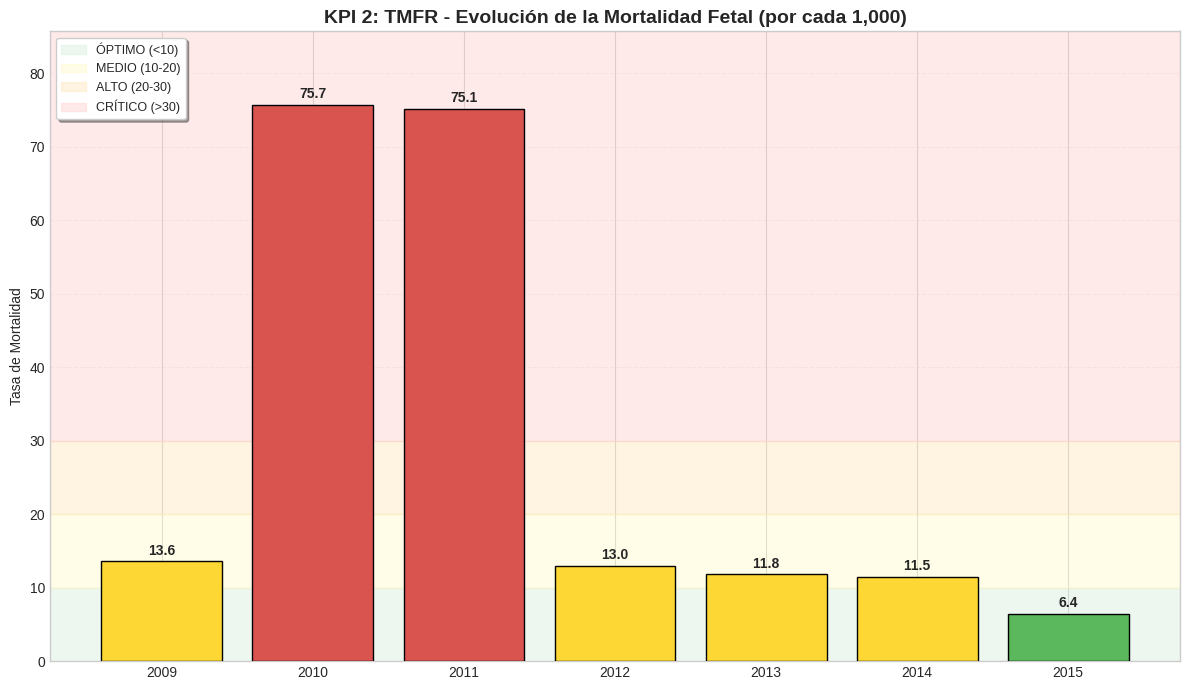


[ESTADO DE MORTALIDAD POR DEPARTAMENTO]
------------------------------------------------------------
🔴 POTOSI      :  96.0 -> [CRÍTICO]
🔴 CHUQUISACA  :  54.0 -> [CRÍTICO]
🔴 LA PAZ      :  40.4 -> [CRÍTICO]
🔴 PANDO       :  36.5 -> [CRÍTICO]
🔴 ORURO       :  36.2 -> [CRÍTICO]
🟠 COCHABAMBA  :  26.2 -> [ALTO]
🟡 BENI        :  20.0 -> [MEDIO]
🟡 TARIJA      :  14.7 -> [MEDIO]
🟢 SANTA CRUZ  :  10.0 -> [ÓPTIMO]
------------------------------------------------------------


In [50]:
# ============================================================================
# KPI 2: TMFR - TASA DE MORTALIDAD FETAL (CONFIGURACIÓN MANUAL)
# ============================================================================

# 1. SELECCIÓN DE AÑOS (Modificable)
anios_incluir = ['2009', '2010', '2011', '2012', '2013', '2014', '2015']
df_kpi = df_total[df_total['anio'].isin(anios_incluir)].copy()

# 2. CÁLCULO PONDERADO POR AÑO (Mortalidad por cada 1,000)
tmfr_anio = df_kpi.groupby('anio').apply(
    lambda x: (x['nacidos_muertos'].sum() /
               x['total_general'].replace(0,1).sum()) * 1000
).reset_index()
tmfr_anio.columns = ['Año', 'TMFR']

# 3. GRÁFICO CON 4 RANGOS DE CONTROL (SEMÁFORO INVERTIDO)
fig, ax = plt.subplots(figsize=(12, 7))

# Definir límites del gráfico
y_max_plot = max(tmfr_anio['TMFR'].max() + 10, 50)
ax.set_ylim(0, y_max_plot)

# Configuración del Semáforo para Mortalidad (Menos es mejor)
ax.axhspan(0, 10, color='#d4edda', alpha=0.4, label='ÓPTIMO (<10)')
ax.axhspan(10, 20, color='#fff9c4', alpha=0.4, label='MEDIO (10-20)')
ax.axhspan(20, 30, color='#ffe5b4', alpha=0.4, label='ALTO (20-30)')
ax.axhspan(30, y_max_plot, color='#ffcccc', alpha=0.4, label='CRÍTICO (>30)')

# Colores de las barras (Invertidos respecto al PAPE)
bar_colors = []
for val in tmfr_anio['TMFR']:
    if val < 10: bar_colors.append('#5cb85c')    # Verde
    elif val < 20: bar_colors.append('#fdd835')  # Amarillo
    elif val < 30: bar_colors.append('#f0ad4e')  # Naranja
    else: bar_colors.append('#d9534f')           # Rojo

bars = ax.bar(tmfr_anio['Año'], tmfr_anio['TMFR'], color=bar_colors, edgecolor='black', zorder=3)

# Etiquetas de datos
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('KPI 2: TMFR - Evolución de la Mortalidad Fetal (por cada 1,000)', fontsize=14, fontweight='bold')
ax.set_ylabel('Tasa de Mortalidad')
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. REPORTE DEPARTAMENTAL PONDERADO
tmfr_depto = df_kpi.groupby('departamento').apply(
    lambda x: (x['nacidos_muertos'].sum() /
               x['total_general'].replace(0,1).sum()) * 1000
).sort_values(ascending=False).reset_index()
tmfr_depto.columns = ['Depto', 'TMFR']

print("\n[ESTADO DE MORTALIDAD POR DEPARTAMENTO]")
print("-" * 60)
for _, row in tmfr_depto.iterrows():
    if row['TMFR'] < 10: status, emoji = "ÓPTIMO", "🟢"
    elif row['TMFR'] < 20: status, emoji = "MEDIO", "🟡"
    elif row['TMFR'] < 30: status, emoji = "ALTO", "🟠"
    else: status, emoji = "CRÍTICO", "🔴"

    print(f"{emoji} {row['Depto']:<12}: {row['TMFR']:>5.1f} -> [{status}]")
print("-" * 60)

### 5.3 KPI 3: Índice de Brecha de Cobertura Institucional (IBC)

**Nombre del indicador:** Porcentaje de Desconexión del Sistema de Salud Institucional.

#### 5.3.1 Fórmula
$$IBC = \left( \frac{\text{Total General} - \text{Nacidos Vivos Atendidos}}{\text{Total General}} \right) \times 100$$

#### 5.3.2 ¿Qué mide?
Este indicador cuantifica la proporción de nacimientos que ocurren fuera del sistema de salud institucional o que no cuentan con registro de asistencia profesional. Es una métrica de "punto ciego" que revela la incapacidad del sistema para captar y proteger eventos vitales.

#### 5.3.3 Semáforo de Control
* 🟢 **ÓPTIMO (0% - 10%):** Alta eficiencia en la captación institucional; brecha mínima de eventos no registrados.
* 🟡 **MEDIO (10% - 30%):** Nivel de desatención moderado; requiere fortalecer brigadas de captación.
* 🟠 **ALTO (30% - 60%):** Brecha de cobertura preocupante; debilidad en la infraestructura o registro.
* 🔴 **CRÍTICO (> 60%):** Desconexión severa; la mayoría de los nacimientos ocurren fuera del control sanitario profesional.

#### 5.3.4 Interpretación
Un IBC elevado señala una crisis de cobertura, donde el sistema de salud no logra llegar a la población. Los valores observados en el análisis actual indican una brecha crítica, sugiriendo que gran parte de los eventos vitales se desarrollan sin el soporte del sistema de salud formal, lo que imposibilita el seguimiento postnatal y la prevención de riesgos.

#### 5.3.5 Referencia y Fuentes
Este indicador es una adaptación técnica del concepto de "brecha de cobertura" (Coverage Gap) utilizado para medir la integridad de los sistemas de información y la equidad en el acceso a la salud.

* **Concepto de Cobertura (OMS):** [WHO - Universal Health Coverage (UHC) Data](https://www.who.int/data/monitoring-universal-health-coverage)

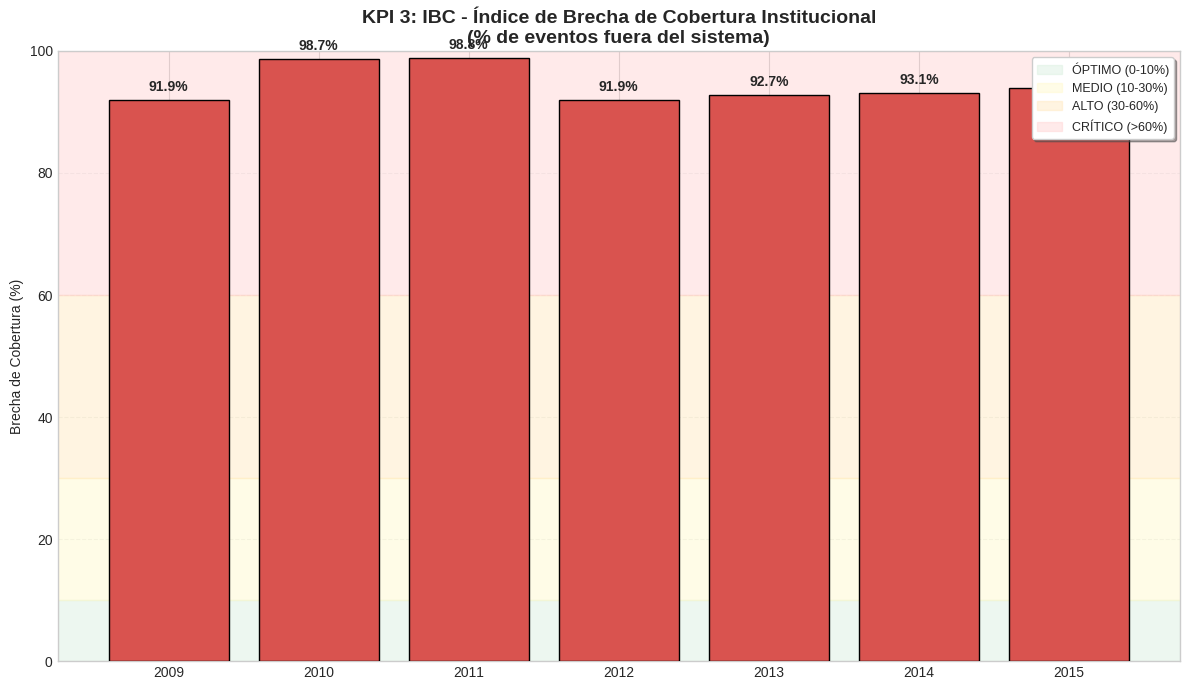


[ESTADO DE BRECHA POR DEPARTAMENTO]
------------------------------------------------------------
🔴 SANTA CRUZ  :  98.8% -> [CRÍTICO]
🔴 TARIJA      :  97.7% -> [CRÍTICO]
🔴 BENI        :  97.3% -> [CRÍTICO]
🔴 COCHABAMBA  :  95.5% -> [CRÍTICO]
🔴 ORURO       :  93.6% -> [CRÍTICO]
🔴 PANDO       :  93.5% -> [CRÍTICO]
🔴 LA PAZ      :  92.1% -> [CRÍTICO]
🔴 CHUQUISACA  :  90.0% -> [CRÍTICO]
🔴 POTOSI      :  79.3% -> [CRÍTICO]
------------------------------------------------------------


In [48]:
# ============================================================================
# KPI 3: IBC - ÍNDICE DE BRECHA DE COBERTURA (CONFIGURACIÓN MANUAL)
# ============================================================================

# 1. SELECCIÓN DE AÑOS
anios_incluir = ['2009', '2010', '2011','2012', '2013', '2014', '2015']
df_kpi = df_total[df_total['anio'].isin(anios_incluir)].copy()

# 2. CÁLCULO PONDERADO POR AÑO (Brecha entre total y atendidos)
def calcular_ibc(df):
    total = df['total_general'].sum()
    atendidos = df['nacidos_vivos_atendidos_por_personal_de_salud'].sum()
    # Brecha = (Eventos no atendidos / Total) * 100
    brecha = ((total - atendidos) / total * 100) if total > 0 else 0
    return max(0, brecha) # Limitar a 0 si el registro es inconsistente (atendidos > total)

ibc_anio = df_kpi.groupby('anio').apply(lambda x: calcular_ibc(x)).reset_index()
ibc_anio.columns = ['Año', 'IBC']

# 3. GRÁFICO CON 4 RANGOS DE CONTROL (SEMÁFORO)
fig, ax = plt.subplots(figsize=(12, 7))

# Configuración del Semáforo (El objetivo es llegar a 0% de brecha)
ax.set_ylim(0, 100)
ax.axhspan(0, 10, color='#d4edda', alpha=0.4, label='ÓPTIMO (0-10%)')
ax.axhspan(10, 30, color='#fff9c4', alpha=0.4, label='MEDIO (10-30%)')
ax.axhspan(30, 60, color='#ffe5b4', alpha=0.4, label='ALTO (30-60%)')
ax.axhspan(60, 100, color='#ffcccc', alpha=0.4, label='CRÍTICO (>60%)')

# Colores de las barras (Más brecha = Peor color)
bar_colors = []
for val in ibc_anio['IBC']:
    if val < 10: bar_colors.append('#5cb85c')    # Verde
    elif val < 30: bar_colors.append('#fdd835')  # Amarillo
    elif val < 60: bar_colors.append('#f0ad4e')  # Naranja
    else: bar_colors.append('#d9534f')           # Rojo

bars = ax.bar(ibc_anio['Año'], ibc_anio['IBC'], color=bar_colors, edgecolor='black', zorder=3)

# Etiquetas de datos
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('KPI 3: IBC - Índice de Brecha de Cobertura Institucional\n(% de eventos fuera del sistema)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Brecha de Cobertura (%)')
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. REPORTE DEPARTAMENTAL PONDERADO
ibc_depto = df_kpi.groupby('departamento').apply(lambda x: calcular_ibc(x)).sort_values(ascending=False).reset_index()
ibc_depto.columns = ['Depto', 'IBC']

print("\n[ESTADO DE BRECHA POR DEPARTAMENTO]")
print("-" * 60)
for _, row in ibc_depto.iterrows():
    if row['IBC'] < 10: status, emoji = "ÓPTIMO", "🟢"
    elif row['IBC'] < 30: status, emoji = "MEDIO", "🟡"
    elif row['IBC'] < 60: status, emoji = "ALTO", "🟠"
    else: status, emoji = "CRÍTICO", "🔴"

    print(f"{emoji} {row['Depto']:<12}: {row['IBC']:>5.1f}% -> [{status}]")
print("-" * 60)

## 6. Identificación de Hallazgos y Problemáticas

A partir del análisis exploratorio de datos (EDA) y la evaluación de los KPIs (PAPE, TMFR e IBC), se han consolidado los siguientes nudos críticos:

---

### 6.1 Deficiencia Crítica en la Integridad de Datos
**Problema:** Se identificaron inconsistencias estructurales en la serie histórica que comprometen la fiabilidad del diagnóstico. Específicamente, en los periodos **2010 y 2011**, los registros muestran una caída anómala en la cobertura de atención (inferior al 2%) en contraste con picos de mortalidad fetal superiores a 44 por cada 1,000 nacimientos. Asimismo, la presencia de valores nulos en variables de atención especializada limita la trazabilidad de los eventos.

**Impacto:** Estas anomalías generan distorsiones estadísticas que impiden un seguimiento lineal confiable, obligando a la exclusión o tratamiento especial de dichos periodos para no sesgar las proyecciones de política pública.

---

### 6.2 Paradoja de Cobertura vs. Mortalidad Fetal
**Problema:** El análisis revela una correlación inversa inesperada: departamentos con mayor registro de atención profesional (como **La Paz, Potosí y Pando**) presentan simultáneamente las tasas más elevadas de mortalidad fetal (superando el promedio nacional de 108.0).

**Impacto:** Este hallazgo evidencia que el registro de atención (cantidad) no es equivalente a la **calidad asistencial**. Sugiere deficiencias severas en los protocolos de control prenatal y resolución de emergencias obstétricas en centros de alta complejidad, donde se concentran los casos críticos.

---

### 6.3 Brecha Crítica en Regiones de Alta Densidad Demográfica
**Problema:** Existe una desproporción alarmante en departamentos con alto volumen de natalidad. El caso de **Santa Cruz**, con más de 400,000 nacimientos registrados, presenta la cobertura institucional más baja del país (aprox. 6%). Esto indica que el crecimiento poblacional ha superado la capacidad de absorción y registro del sistema de salud formal.

**Impacto:** La existencia de este "punto ciego" institucional dificulta la planificación de servicios postnatales, programas de inmunización y asignación de presupuesto per cápita, dejando a una gran proporción de la población neonatal fuera del radar de protección del Estado.

## 7. Propuesta Data-Driven y Roadmap de Mejora

A partir de los hallazgos identificados en el diagnóstico, se proponen tres ejes estratégicos para transformar los datos en activos de decisión para el sistema de salud:

---

### 7.1 Implementación de Business Intelligence con Enfoque Territorial
**Propuesta:** Desarrollar un ecosistema de visualización centralizado que integre los registros de nacimientos con capas geoespaciales (GeoJSON).
* **Alcance:** Implementación de mapas de calor a nivel departamental y municipal para los KPIs estratégicos (**PAPE, TMFR, IBC**).
* **Valor Agregado:** Permitirá la identificación inmediata de clústeres de alta mortalidad y zonas de baja captación institucional, facilitando la movilización de brigadas de salud y la optimización de recursos financieros en los territorios con mayores brechas de atención.

---

### 7.2 Institucionalización de KPIs de Monitoreo Continuo
**Propuesta:** Establecer los tres indicadores desarrollados en este análisis como métricas estándar dentro del Sistema Nacional de Información en Salud (SNIS).
* **Alcance:** Integración de **PAPE, TMFR e IBC** en los reportes trimestrales de gestión hospitalaria y salud pública.
* **Valor Agregado:** Proporciona una línea base estandarizada para comparar el desempeño interdepartamental, permitiendo detectar desviaciones críticas en tiempo real y evaluar el impacto de las políticas de salud materno-neonatal a mediano plazo.

---

### 7.3 Protocolo de Gobernanza y Calidad de Datos (Data Quality)
**Propuesta:** Ejecutar un marco de gobernanza que asegure la integridad de la carga de datos en el origen.
* **Alcance:**
    1.  **Validación Automática:** Reglas de negocio en el software de captura para rechazar registros inconsistentes (ej. coberturas > 100% o valores negativos).
    2.  **Estandarización:** Creación de un diccionario de datos único con metadatos claros y campos obligatorios.
    3.  **Auditoría:** Procesos de conciliación periódica entre registros físicos y digitales.
* **Valor Agregado:** Garantiza que el 100% de la información sea apta para el análisis predictivo y estratégico, eliminando los "puntos ciegos" y las anomalías observadas en series históricas previas.

## 8. Conclusiones Generales

El diagnóstico *data-driven* sobre los registros de natalidad en Bolivia (2009-2015) constituye una base analítica sólida para identificar las fortalezas y vulnerabilidades críticas del sistema de información en salud y la atención materna en el país.

---

### 8.1 Hallazgos Estratégicos
* **Crecimiento de la Demanda:** Se registró un incremento sostenido del **20.2%** en la natalidad durante el periodo analizado, alcanzando un pico de **205,539 nacimientos en 2015**, lo que presiona la capacidad instalada de los servicios neonatales.
* **Inconsistencias de Registro:** Los periodos **2010 y 2011** actúan como "puntos ciegos" estadísticos, con coberturas reportadas inferiores al 2% y picos de mortalidad fetal (>44 por cada 1,000), confirmando fallas severas en la captura de datos en origen.
* **Disparidad Geográfica Extrema:** Los reportes de cobertura muestran brechas inverosímiles: desde un **5.9% en Santa Cruz** hasta valores de sobre-registro en **La Paz**, sugiriendo una falta de estandarización en los criterios de reporte departamental.
* **Calidad vs. Cantidad:** Los departamentos con mayor volumen de atención registrada (**Potosí, La Paz y Pando**) mantienen las tasas de mortalidad fetal más altas, superando el promedio nacional de 108.0. Esto confirma que el registro administrativo de atención no es un indicador de éxito clínico *per se*.

---

### 8.2 El Valor de la Analítica de Datos
La transición de datos crudos a **KPIs estratégicos (PAPE, TMFR, IBC)** ha permitido transformar registros administrativos en inteligencia sanitaria. Este enfoque supera la gestión basada en intuiciones, permitiendo:
1.  Cuantificar brechas de cobertura con precisión matemática.
2.  Identificar patrones de riesgo ocultos en grandes volúmenes de datos.
3.  Priorizar la asignación de recursos basada en evidencia objetiva.

---

### 8.3 Impacto en la Gobernanza Sanitaria
Los resultados de este proyecto trazan una hoja de ruta clara para la toma de decisiones:
* **Focalización Clínica:** Intervención urgente en protocolos prenatales en el eje Potosí-La Paz-Pando.
* **Fortalecimiento Institucional:** Optimizar el registro y captación en Santa Cruz y Beni para eliminar el subregistro.
* **Transformación Digital:** Desplegar dashboards territoriales para el monitoreo de KPIs en tiempo real.
* **Gobernanza de Datos:** Establecer reglas de validación que aseguren la integridad del SNIS.

**Conclusión Final:** La disponibilidad de datos confiables no es un fin, sino el habilitador indispensable para diseñar políticas públicas equitativas y efectivas que garanticen la seguridad materno-neonatal en Bolivia.